# 3 · Models, and registering your own

A model maps parameters to predicted flux:

```
predict(parameters: dict, times: array, bands: array) -> flux [Jy]
```

That is the whole contract. This notebook walks the built-ins, binds one of redback's models,
and registers a model written from scratch.

**Needs:** the base install. The redback section needs the `[models]` extra.

In [1]:
from pathlib import Path

# Works whether the notebook is run from notebooks/ or from the repository root.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "tests" / "data").is_dir())
AT2017GFO = ROOT / "tests" / "data" / "at2017gfo.csv"

import warnings
warnings.filterwarnings("ignore")           # keep the tutorial output readable

import numpy as np
import matplotlib.pyplot as plt
import whisper_cbpf as wp

print("whisper_cbpf", wp.__version__)

whisper_cbpf 0.2.0


## What is registered

In [2]:
for name in wp.list_models():
    m = wp.get_model(name)
    print(f"  {name:24s} {len(m.parameters)} params  {m.parameters}")

  bazin                    4 params  ['amplitude', 't0', 'tau_rise', 'tau_fall']
  flare                    3 params  ['amplitude', 'rise_time', 'decay_time']
  flare_jax                4 params  ['log_amp', 'log_sigma', 'log_tau', 't0']
  gaussian_rise            4 params  ['amplitude', 't0', 'sigma_rise', 'tau_decay']
  mck19                    5 params  ['v_kick', 'M_smbh', 'M_bh', 'r_bh', 'redshift']
  two_component_kilonova   9 params  ['mej_1', 'vej_1', 'kappa_1', 'temperature_floor_1', 'mej_2', 'vej_2', 'kappa_2', 'temperature_floor_2', 'redshift']


## Evaluating one

`get_model` returns a `Model`. Its `parameters` list fixes the order everywhere else — priors,
posterior columns, the flat `theta` the JAX samplers use.

In [3]:
bazin = wp.get_model("bazin")
print(bazin.description)
print("parameters:", bazin.parameters)
print()
print(bazin.default_prior)

Bazin (2009): A*exp(-(t-t0)/tau_fall) / (1 + exp(-(t-t0)/tau_rise)).
parameters: ['amplitude', 't0', 'tau_rise', 'tau_fall']

Prior({'amplitude': Uniform(0.0, 10.0), 't0': Uniform(-10.0, 30.0), 'tau_rise': Uniform(0.1, 20.0), 'tau_fall': Uniform(0.5, 60.0)})


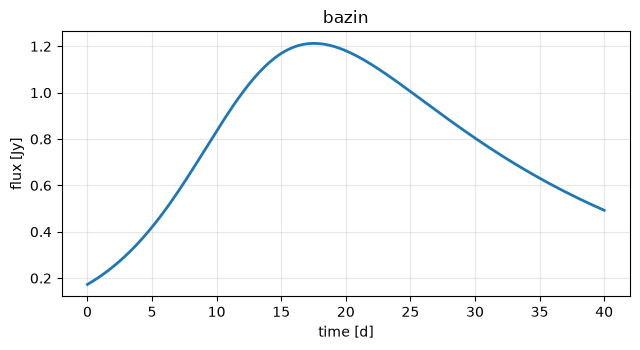

In [4]:
times = np.linspace(0.0, 40.0, 200)
bands = np.array(["g"] * times.size)

params = {"amplitude": 2.0, "t0": 12.0, "tau_rise": 4.0, "tau_fall": 20.0}
flux = bazin.predict(params, times, bands)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(times, flux, lw=2)
ax.set_xlabel("time [d]"); ax.set_ylabel("flux [Jy]"); ax.set_title("bazin")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## The empirical shapes side by side

`bazin`, `gaussian_rise` and `flare` are three ways of writing "rises, then falls". They cost
nothing to evaluate, which makes them the right thing to develop a pipeline against.

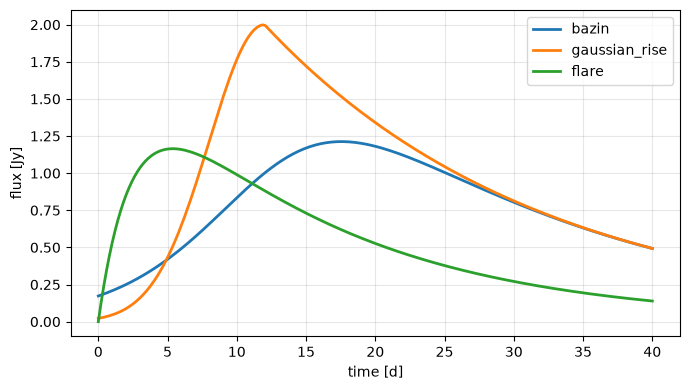

In [5]:
demo = {
    "bazin":         {"amplitude": 2.0, "t0": 12.0, "tau_rise": 4.0, "tau_fall": 20.0},
    "gaussian_rise": {"amplitude": 2.0, "t0": 12.0, "sigma_rise": 4.0, "tau_decay": 20.0},
    "flare":         {"amplitude": 2.0, "rise_time": 3.0, "decay_time": 15.0},   # starts at t = 0
}

fig, ax = plt.subplots(figsize=(7, 4))
for name, p in demo.items():
    ax.plot(times, wp.get_model(name).predict(p, times, bands), lw=2, label=name)
ax.set_xlabel("time [d]"); ax.set_ylabel("flux [Jy]"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## `mck19` — an analytic physical model

McKernan et al. (2019): a flare from a stellar-mass black-hole merger inside an AGN disc. Analytic,
so it needs no extra dependency, but its parameters are physical.

In [6]:
mck = wp.get_model("mck19")
print("parameters:", mck.parameters)
print(mck.default_prior)

parameters: ['v_kick', 'M_smbh', 'M_bh', 'r_bh', 'redshift']
Prior({'v_kick': Uniform(100.0, 800.0), 'M_smbh': LogUniform(1000000.0, 1000000000.0), 'M_bh': Uniform(20.0, 160.0), 'r_bh': LogUniform(500.0, 10000.0), 'redshift': Uniform(0.01, 1.0)})


## Binding one of redback's models

`register_redback` reads the parameter names from the function signature and the prior from
redback's own `.prior` file, so nothing is transcribed and nothing can drift. Any of redback's
photometric models works the same way; its bolometric engines are refused, because they return a
luminosity, not a flux density.

The binding integrates redback's spectrum over each band's filter (a bare `g` is LSST g; see
notebook 2), and applies redback's constraint priors as a hard wall: a draw that breaks one, such
as ejecta with more kinetic energy than their nickel could supply, predicts zero flux. The
model's `description` records both.

In [7]:
import textwrap

try:
    m = wp.register_redback("arnett", redshift=0.05)
    print("registered:", m.name)
    print("parameters:", m.parameters)
    print()
    print(m.default_prior)
    print()
    print(textwrap.fill(m.description, 100))
except ImportError as exc:
    print("needs the [models] extra:", exc)

21:24 redback WARNING : No module named 'lalsimulation'


21:24 redback WARNING : lalsimulation is not installed. Some EOS based models will not work. Please use bilby eos or pass your own EOS generation class to the model


21:24 bilby INFO    : Running bilby version: 2.8.2


21:24 redback INFO    : Running redback version: 1.20.0


registered: arnett_redback
parameters: ['f_nickel', 'mej', 'vej', 'kappa', 'kappa_gamma', 'temperature_floor']

Prior({'f_nickel': LogUniform(0.001, 1.0), 'mej': LogUniform(0.0001, 100.0), 'vej': LogUniform(1000.0, 100000.0), 'kappa': Uniform(0.05, 2.0), 'kappa_gamma': LogUniform(0.0001, 10000.0), 'temperature_floor': LogUniform(1000.0, 100000.0)})

redback 'arnett' (CPU); redback flux_density [mJy] integrated over each band's filter
(whisper_cbpf.synphot) -> flux density (Jy); pinned redshift=0.05; redback's constraints 0 <
emax_constraint < 1 are a hard wall (zero flux outside), with the nuclear-burning energy corrected
to 1.51e18 erg/g (redback: 1.91e19; constraint='redback' keeps it).


In [8]:
from whisper_cbpf.models import redback_adapter as rb

# `redback_model` builds the Model without putting it in the registry -- useful when you want to
# hold several bindings of the same redback model at different redshifts.
try:
    m2 = wp.redback_model("arnett", redshift=0.2, name="arnett_z02")
    print("built (not registered):", m2.name, "|", "arnett_z02" in wp.list_models())
except ImportError as exc:
    print("needs the [models] extra:", exc)

# A delta prior in redback means "redback fixed this", so it becomes a pinned value, not a parameter.
print("pinned by type_1a.prior:", rb.redback_pinned("type_1a"))
print("redback's luminosity distance at z=0.0098:", f"{rb.redback_luminosity_distance_cm(0.0098):.5e} cm")
print("this redback applies the (1+z) flux factor:", rb.redback_applies_dilation("arnett"))

built (not registered): arnett_z02 | False
pinned by type_1a.prior: {'line_wavelength': 6500.0, 'line_width': 500.0, 'line_amplitude': 0.3}
redback's luminosity distance at z=0.0098: 1.34991e+26 cm
this redback applies the (1+z) flux factor: True


## Registering your own

Two rules. Define `predict` at **module level**, not as a closure or lambda, or parallel ABC
(`n_jobs > 1`) cannot pickle it. And return flux in **janskys**.

In [9]:
def stretched_exp(parameters, times, bands=None):
    """A rise with a stretched-exponential decay."""
    t = np.asarray(times, dtype=float)
    dt = t - parameters["t0"]
    rise = 1.0 - np.exp(-np.clip(dt, 0.0, None) / parameters["tau_rise"])
    decay = np.exp(-(np.clip(dt, 0.0, None) / parameters["tau_fall"]) ** parameters["beta"])
    return parameters["amplitude"] * rise * decay


prior = wp.Prior({
    "amplitude": wp.Uniform(0.0, 5.0, name="amplitude"),
    "t0":        wp.Uniform(0.0, 20.0, name="t0"),
    "tau_rise":  wp.LogUniform(0.5, 20.0, name="tau_rise"),
    "tau_fall":  wp.LogUniform(1.0, 60.0, name="tau_fall"),
    "beta":      wp.Uniform(0.3, 3.0, name="beta"),
})

wp.register_model("stretched_exp", stretched_exp,
                  ["amplitude", "t0", "tau_rise", "tau_fall", "beta"],
                  prior=prior, description="Rise with a stretched-exponential decay.",
                  overwrite=True)

print("stretched_exp" in wp.list_models())

True


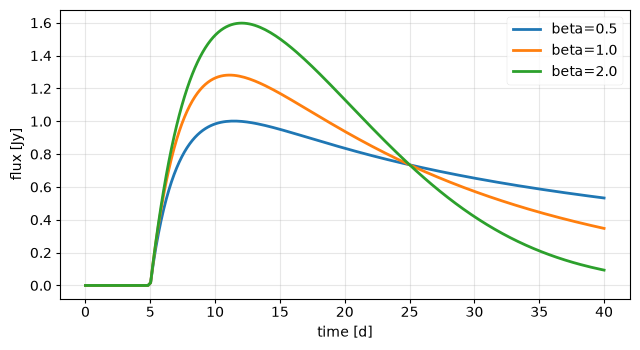

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for beta in (0.5, 1.0, 2.0):
    p = {"amplitude": 2.0, "t0": 5.0, "tau_rise": 3.0, "tau_fall": 20.0, "beta": beta}
    ax.plot(times, wp.get_model("stretched_exp").predict(p, times, bands), lw=2, label=f"beta={beta}")
ax.set_xlabel("time [d]"); ax.set_ylabel("flux [Jy]"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Where next

* [04 · Priors, likelihoods and distances](04_priors_and_likelihoods.ipynb)
* [05 · CPU samplers](05_cpu_samplers.ipynb) — fit the model you just registered.
* [06 · JAX physical models](06_jax_physical_models.ipynb) — kilonovae, TDEs, supernovae.